# Final Project 2 (Using NIRCAM image of NGC 3324)

In [1]:
import numpy as np
import sep

In [2]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

## Read image into standard 2-d numpy array

In [3]:
fits_image_filename = 'jw02731-o001_t017_nircam_clear-f090w_i2d.fits'
with fits.open(fits_image_filename) as hdul:  # open a FITS file
    data = hdul[1].data

## Show the image and save as image_plot.png

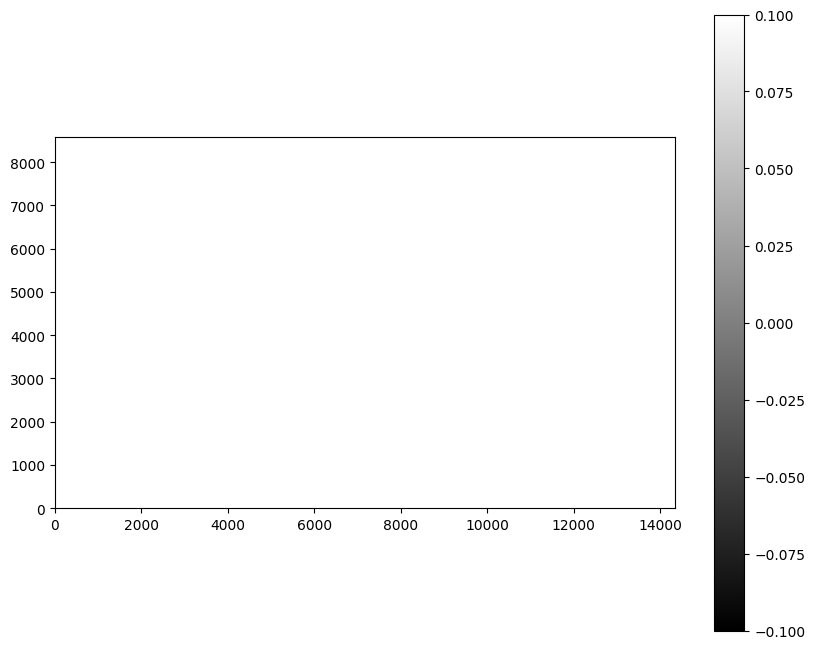

In [4]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

## Measure a spatially varying background on the image

In [5]:
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data)

## Get a "global" mean and noise of the image background:

In [6]:
print(bkg.globalback)
print(bkg.globalrms)

1.1997147798538208
0.06582547724246979


## Evaluate background as 2-d array, same size as original image

In [7]:
bkg_image = bkg.back()

## Show the background and save as background_plot.png

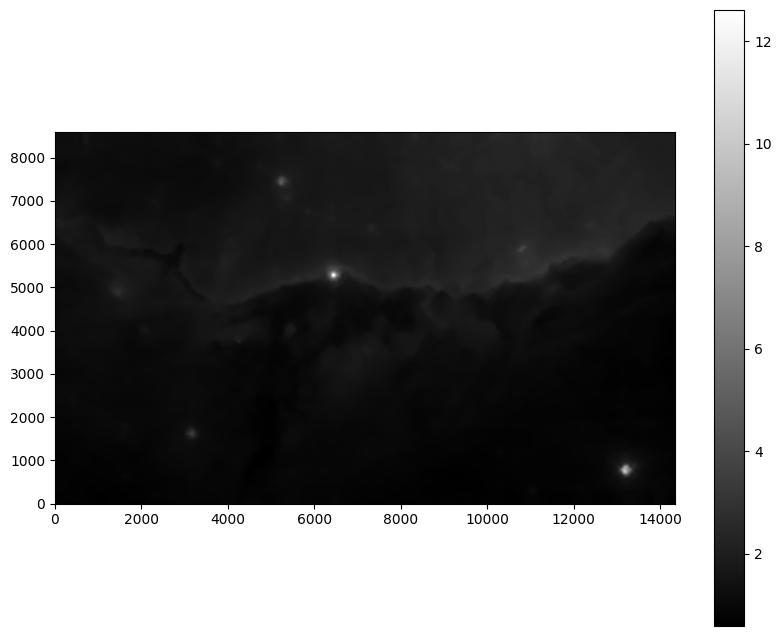

In [8]:
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

plt.savefig('background_plot.png')

## Evaluate the background noise as 2-d array, same size as original image

In [9]:
bkg_rms = bkg.rms()

## Show the background noise and save the figure as background_noise.png

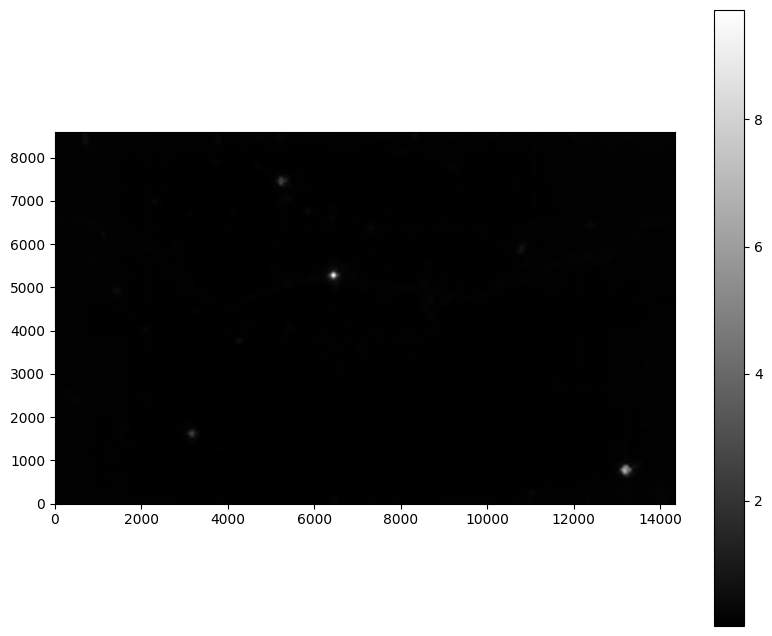

In [10]:
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

plt.savefig('background_noise.png')

## Subtract the background

In [11]:
data_sub = data - bkg

## Detect objects and set the detection threshold to be a constant value of 1.5 standard deviations

In [12]:
objects = sep.extract(data_sub, 1.5, err=bkg.globalrms)

Exception: internal pixel buffer full: The limit of 300000 active object pixels over the detection threshold was reached. Check that the image is background subtracted and the detection threshold is not too low. If you need to increase the limit, use set_extract_pixstack.

## Print how many objects were detected

In [13]:
len(objects)

NameError: name 'objects' is not defined

## Over-plot the object coordinates with some basic shape parameters on the image and then save figure as image_coordinates.png

NameError: name 'objects' is not defined

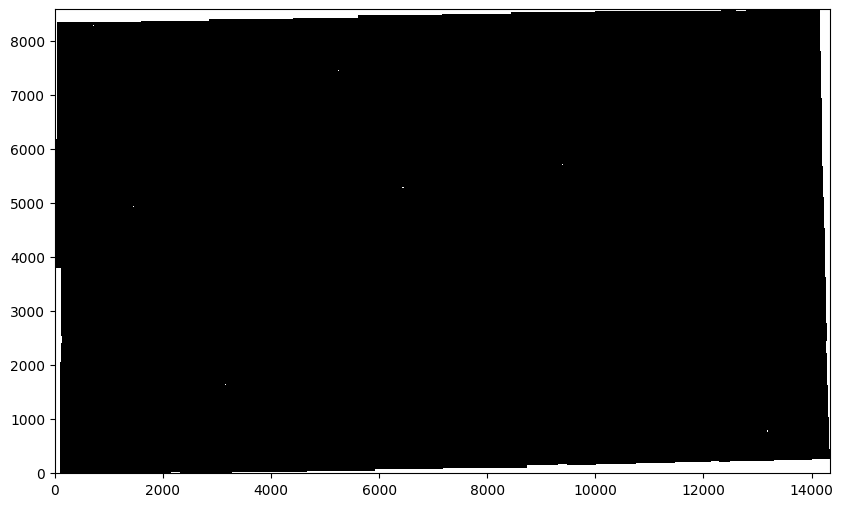

In [14]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.savefig('image_coordinates.png')

## List the available object fields

In [15]:
objects.dtype.names

NameError: name 'objects' is not defined

## Perform simple circular aperture photometry with a 3 pixel radius at the locations of the objects

In [16]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0)

NameError: name 'objects' is not defined

## Show the first 10 objects results:

In [17]:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

NameError: name 'flux' is not defined

# Step 7

In [18]:
print("Mean of fluxes:", np.mean(flux))
print("Median of fluxes:", np.median(flux))
print("Standard deviation of fluxes:", np.std(flux))

NameError: name 'flux' is not defined

# Step 8

In [19]:
# ---------------------------------
# 0. Copy all this script into one cell, between steps 7 and 8 of your final project
#    You will need to install the "reproject" package with pip
#    This script will "reproject" all images onto the same shape using one image as a reference
# ---------------------------------

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp

# ---------------------------------
# 1. Load your reference image
#    This will define the WCS and shape for all others
# ---------------------------------
file_reference = 'jw02731-o001_t017_nircam_clear-f090w_i2d.fits'
with fits.open(file_reference) as hdulist:
    # For JWST i2d images, 'SCI' is commonly the science extension
    ref_header = hdulist['SCI'].header
    ref_data = hdulist['SCI'].data

# Create a WCS object from the reference
ref_wcs = WCS(ref_header)

# This shape will be used for all reprojected images
output_shape = ref_data.shape

# ---------------------------------
# 2. Reproject the other images
# ---------------------------------
fname1 = jw02731-o001_t017_nircam_clear-f187n_i2d.fits
fname2 = jw02731-o001_t017_nircam_clear-f200w_i2d.fits
fname3 = jw02731-o001_t017_nircam_clear-f335m_i2d.fits
fname4 = jw02731-o001_t017_nircam_clear-f444w_i2d.fits
fname5 = jw02731-o001_t017_nircam_f444w-f470n_i2d.fits

other_filenames = [
    fname1,
    fname2,
    fname3,
    fname4,
    fname5,
]

# Reproject all other files according to the reference
for fname in other_filenames:
    with fits.open(fname) as hdulist:
        data = hdulist['SCI'].data
        header = hdulist['SCI'].header
        wcs_in = WCS(header)
    
    # Reproject this image onto the reference WCS
    # reproject_interp returns (reprojected_data, footprint)
    reprojected_data, footprint = reproject_interp(
        (data, wcs_in),
        ref_wcs,
        shape_out=output_shape
    )

    # Optionally, update the header to match the reference WCS
    # so that the new FITS is self-consistent
    new_header = ref_header.copy()

    # Save the new file
    out_name = fname.replace('.fits', '_reproj.fits')
    hdu = fits.PrimaryHDU(reprojected_data, header=new_header)
    hdu.writeto(out_name, overwrite=True)
    print(f"Reprojected {fname} -> {out_name}")

Set DATE-AVG to '2022-06-03T12:17:28.687' from MJD-AVG.
Set DATE-END to '2022-06-03T14:54:43.830' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.567170 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654335564.228 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


NameError: name 'jw02731' is not defined